In [27]:
import numpy as np
import pickle
import pandas as pd
import os
import torch
import torch.nn as nn
import xgboost as xgb
from sklearn.multioutput import MultiOutputRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

from google.colab import drive
drive.mount('/content/drive')
%cd /content/drive/MyDrive/ICAIF_2024_cryptocurreny_hackathon_starting_kit

with open("/content/drive/MyDrive/datasource/ref_log_return.pkl", "rb") as f:
    loaded_array = pickle.load(f)
train_log_return = torch.tensor(loaded_array)
print(train_log_return.shape)

with open("/content/drive/MyDrive/datasource/ref_price.pkl", "rb") as f:
    loaded_array = pickle.load(f)
train_init_price = torch.tensor(loaded_array)
print(train_init_price.shape)

log_returns = train_log_return.numpy()
target = train_init_price.numpy()

X = log_returns[:-24]
Y = log_returns[24:]


X_flat = X.reshape(X.shape[0], -1)
Y_flat = Y.reshape(Y.shape[0], -1)


train_size = int(0.8 * X_flat.shape[0])
X_train = X_flat[:train_size]
X_test  = X_flat[train_size:]
y_train = Y_flat[:train_size]
y_test  = Y_flat[train_size:]

model = MultiOutputRegressor(
    xgb.XGBRegressor(
        n_estimators=100,
        learning_rate=0.1
    )
)

model.fit(X_train, y_train)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/ICAIF_2024_cryptocurreny_hackathon_starting_kit
torch.Size([8937, 24, 3])
torch.Size([8937, 1, 3])


MultiOutputRegressor(estimator=XGBRegressor(base_score=None, booster=None,
                                            callbacks=None,
                                            colsample_bylevel=None,
                                            colsample_bynode=None,
                                            colsample_bytree=None, device=None,
                                            early_stopping_rounds=None,
                                            enable_categorical=False,
                                            eval_metric=None,
                                            feature_types=None, gamma=None,
                                            grow_policy=None,
                                            importance_type=None,
                                            interaction_constraints=None,
                                            learning_rate=0.1, max_bin=None,
                                            max_cat_threshold=None,
                                            max_cat_to_onehot=None,
                                            max_delta_step=None, max_depth=None,
                                            max_leaves=None,
                                            min_child_weight=None, missing=nan,
                                            monotone_constraints=None,
                                            multi_strategy=None,
                                            n_estimators=100, n_jobs=None,
                                            num_parallel_tree=None,
                                            random_state=None, ...))

In [28]:
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
print("Test MSE (72 đầu ra):", mse)

Test MSE (72 đầu ra): 4.45713521912694e-05


In [29]:
last_window = X[-1].reshape(1, -1)

forecast_log_return = model.predict(last_window).reshape(24, 3)
print("Dự báo log-return (24h, 3 coin):")
print(forecast_log_return)

Dự báo log-return (24h, 3 coin):
[[-2.0151567e-03 -2.4438701e-03  1.3241791e-03]
 [-6.3409243e-04 -1.0790813e-03 -6.4208085e-04]
 [-1.4473987e-03 -1.2343169e-04  3.4512285e-04]
 [-1.2876406e-04 -2.4747520e-04  1.2199885e-03]
 [-9.1778429e-04  7.6712000e-05 -7.5683539e-04]
 [ 5.0718733e-04  3.2364842e-04 -7.9750124e-04]
 [-2.7746166e-04 -2.4085608e-03  1.8700998e-04]
 [ 5.4437749e-04  2.6182350e-04 -7.4073445e-04]
 [-1.4425897e-03 -1.4599060e-03 -5.8320293e-04]
 [-9.8195917e-04  1.0122309e-03 -1.3312139e-03]
 [ 1.5659509e-05  2.8864534e-03  2.2282512e-03]
 [ 2.4408509e-03  9.3343022e-04  9.9630805e-04]
 [ 5.0752721e-04 -1.4074139e-03  5.8506610e-04]
 [-3.5505064e-04  1.1735385e-03 -4.9293437e-03]
 [ 8.1295689e-04  1.7180961e-03  1.6118916e-03]
 [-1.2621145e-03 -3.7507121e-03 -3.7447556e-03]
 [ 9.1736857e-04 -1.7072441e-03 -1.0783396e-03]
 [ 5.4028950e-04  4.8715486e-03  1.0694730e-03]
 [ 5.9590087e-04 -1.6012576e-03  1.8218275e-04]
 [ 1.1162279e-03 -1.2128686e-03  1.2344840e-03]
 [-5.04

In [30]:
def log_return_to_price(init_price, forecast_log):
    """
    init_price: np.array shape (3,)  -- giá ban đầu cho 3 coin
    forecast_log: np.array shape (24, 3) -- log-return dự báo 24h

    return: price_path shape (24, 3)
            (giá tại từng giờ cho 24 giờ tiếp theo)
    """
    # Tính log-return tích lũy
    cum_log = np.cumsum(forecast_log, axis=0)  # (24,3)
    # e^(cumulative log-return) * init_price
    price_path = init_price * np.exp(cum_log)
    return price_path

# train_init_price shape: (8937, 1, 3)
init_price_data = train_init_price[-1, 0]  # shape (3,)

# Chuyển forecast_log_return sang giá
forecast_price_path = log_return_to_price(init_price_data, forecast_log_return)
print("Giá dự báo (24 giờ, 3 coin):")
print(forecast_price_path)

def compute_hourly_return(price_path):
    """
    price_path: shape (24, 3)
    return: shape (23, 3) - % thay đổi giữa giờ t và t-1
    """
    # p[t] - p[t-1] / p[t-1]
    returns = (price_path[1:] - price_path[:-1]) / price_path[:-1]
    return returns

def compute_var(returns, alpha=0.05):
    """
    returns: shape (n, 3) -> ta flatten để có 1D
    alpha: mức cắt (thường 5% hoặc 1%)
    VaR = percentile(returns, alpha)
    """
    r = returns.flatten()
    var_val = np.percentile(r, 100*alpha)
    return var_val

def compute_es(returns, alpha=0.05):
    """
    Expected Shortfall = trung bình các return <= VaR
    """
    r = returns.flatten()
    var_val = np.percentile(r, 100*alpha)
    tail_losses = r[r <= var_val]
    if len(tail_losses) == 0:
        return var_val  # Trường hợp hiếm
    es_val = tail_losses.mean()
    return es_val

def compute_cumulative_pnl(price_path):
    """
    price_path: (24, 3)
    => PnL = (price cuối - price đầu) / price đầu
    => shape (3,) cho 3 coin
    """
    initial_price = price_path[0]
    final_price = price_path[-1]
    pnl = (final_price - initial_price) / initial_price
    return pnl  # (3,)

def compute_max_drawdown(price_path):
    # Nếu price_path là torch.Tensor, chuyển về numpy
    if isinstance(price_path, torch.Tensor):
        price_path = price_path.detach().cpu().numpy()

    mdd = []
    for c in range(price_path.shape[1]):  # giả sử price_path có shape (T, 3)
        prices_c = price_path[:, c]
        peak = np.maximum.accumulate(prices_c)
        drawdown = (peak - prices_c) / peak
        max_dd = np.max(drawdown)  # np.max hoạt động trên mảng numpy
        mdd.append(max_dd)
    return np.array(mdd)


# 5.1 Tính return giữa các giờ
hourly_returns = compute_hourly_return(forecast_price_path)  # shape (23, 3)

# 5.2 Tính VaR và ES (ví dụ alpha=5%)
alpha = 0.05
var_val = compute_var(hourly_returns, alpha=alpha)
es_val = compute_es(hourly_returns, alpha=alpha)
print(f"VaR({int(alpha*100)}%): {var_val}")
print(f"ES({int(alpha*100)}%): {es_val}")

# 5.3 Tính Cumulative PnL
pnl = compute_cumulative_pnl(forecast_price_path)
print("Cumulative PnL (tương đối) cho 3 coin:", pnl)

# 5.4 Tính Maximum Drawdown
mdd = compute_max_drawdown(forecast_price_path)
print("Maximum Drawdown cho 3 coin:", mdd)


Giá dự báo (24 giờ, 3 coin):
tensor([[30510.1230,  1915.9718,   246.8767],
        [30490.7773,  1913.9055,   246.7182],
        [30446.6777,  1913.6693,   246.8034],
        [30442.7578,  1913.1959,   247.1047],
        [30414.8320,  1913.3425,   246.9177],
        [30430.2598,  1913.9619,   246.7209],
        [30421.8184,  1909.3575,   246.7670],
        [30438.3867,  1909.8574,   246.5843],
        [30394.5039,  1907.0712,   246.4405],
        [30364.6758,  1909.0026,   246.1127],
        [30365.1484,  1914.5208,   246.6617],
        [30439.3574,  1916.3090,   246.9076],
        [30454.8105,  1913.6136,   247.0521],
        [30443.9980,  1915.8607,   245.8373],
        [30468.7598,  1919.1553,   246.2339],
        [30430.3281,  1911.9705,   245.3135],
        [30458.2559,  1908.7091,   245.0491],
        [30474.7188,  1918.0303,   245.3113],
        [30492.8848,  1914.9614,   245.3560],
        [30526.9395,  1912.6401,   245.6591],
        [30511.5449,  1910.7848,   246.0463],
     

<ipython-input-30-599641aed81b>:12: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  price_path = init_price * np.exp(cum_log)


In [31]:
print("init_price_data.shape:", init_price_data.shape)

init_price_data.shape: torch.Size([3])


In [32]:
init_price_data = train_init_price
def check_alignment(idx_list=[0, 100, 500, -1]):
    """
    In ra log_returns[idx], init_price_data[idx]
    để xác thực index khớp nhau
    """
    for idx in idx_list:
        print(f"\n--- Checking index {idx} ---")
        print("log_returns[idx] shape:", log_returns[idx].shape)
        print("init_price_data[idx]:", init_price_data[idx])
        # So sánh log_returns[idx, 0, :] & init_price_data[idx] xem logic

check_alignment()



--- Checking index 0 ---
log_returns[idx] shape: (24, 3)
init_price_data[idx]: tensor([[26489.4453,  1840.9900,   261.9500]])

--- Checking index 100 ---
log_returns[idx] shape: (24, 3)
init_price_data[idx]: tensor([[48071.5898,  2494.5200,   319.5500]])

--- Checking index 500 ---
log_returns[idx] shape: (24, 3)
init_price_data[idx]: tensor([[9577.4805,  192.7350,   18.7819]])

--- Checking index -1 ---
log_returns[idx] shape: (24, 3)
init_price_data[idx]: tensor([[30571.6641,  1920.6600,   246.5500]])


In [33]:
# Tạo list để lưu trữ returns (từng giờ) của toàn bộ test set
all_hourly_returns = []
all_pnl = []

# Vòng lặp qua từng sample trong X_test
for i in range(X_test.shape[0]):
    # Tìm chỉ số "toàn cục" trong X
    global_idx = i + train_size  # do X_test bắt đầu từ train_size

    # Lấy init price tương ứng
    # X[global_idx] = log_returns[global_idx], => init_price_data[global_idx]
    init_p = init_price_data[global_idx, 0]  # shape (3,)

    # Dự báo log-return 24h
    x_input = X_test[i].reshape(1, -1)       # (1,72)
    forecast_log = model.predict(x_input).reshape(24, 3)

    # Chuyển sang giá
    price_path = log_return_to_price(init_p, forecast_log)

    # Tính return từng giờ
    hr_return = compute_hourly_return(price_path)  # (23,3)
    all_hourly_returns.append(hr_return)

    # Tính PnL
    pnl = compute_cumulative_pnl(price_path)  # (3,)
    all_pnl.append(pnl)

# Ghép thành mảng
all_hourly_returns = np.concatenate(all_hourly_returns, axis=0)  # shape (~ 23*test_size, 3)
all_pnl = np.stack(all_pnl, axis=0)  # shape (test_size, 3)

print("all_hourly_returns shape:", all_hourly_returns.shape)
print("all_pnl shape:", all_pnl.shape)


<ipython-input-30-599641aed81b>:12: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  price_path = init_price * np.exp(cum_log)


all_hourly_returns shape: (41009, 3)
all_pnl shape: (1783, 3)


In [34]:
# Flatten ra 1D
r = all_hourly_returns.flatten()

alpha = 0.05
var_val = compute_var(r, alpha)
es_val = compute_es(r, alpha)
print(f"VaR({int(alpha*100)}%): {var_val}")
print(f"ES({int(alpha*100)}%): {es_val}")


VaR(5%): -0.002425385871902108
ES(5%): -0.0038029802963137627


In [35]:
coin2_pnl = all_pnl[:,1]  # cột 1
print("Coin2 PnL stats:")
print("  Mean:", coin2_pnl.mean())
print("  Min:", coin2_pnl.min())
print("  Max:", coin2_pnl.max())


Coin2 PnL stats:
  Mean: -0.000780187
  Min: -0.04609322
  Max: 0.0363216


In [36]:
last_idx = X.shape[0] - 1  # = N-1
last_init_p = init_price_data[last_idx, 0]  # shape (3,)

# Dự báo
last_input = X[last_idx].reshape(1, -1)  # shape (1,72)
last_forecast_log = model.predict(last_input).reshape(24,3)

# Chuyển thành giá
last_price_path = log_return_to_price(last_init_p, last_forecast_log)

# In ra initial price vs final price
print("=== Kiểm tra mẫu cuối cùng ===")
print("Initial price (3 coin):", last_init_p)
print("Final price (3 coin):", last_price_path[-1])

# PnL
last_pnl = compute_cumulative_pnl(last_price_path)
print("PnL (3 coin):", last_pnl)

# MDD
last_mdd = compute_max_drawdown(last_price_path)
print("MDD (3 coin):", last_mdd)


=== Kiểm tra mẫu cuối cùng ===
Initial price (3 coin): tensor([63482.1367,  3066.9351,   550.5000])
Final price (3 coin): tensor([63399.6133,  3032.5613,   547.2451])
PnL (3 coin): tensor([ 0.0007, -0.0088, -0.0072])
MDD (3 coin): [0.00476715 0.01043257 0.00831865]


<ipython-input-30-599641aed81b>:12: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  price_path = init_price * np.exp(cum_log)


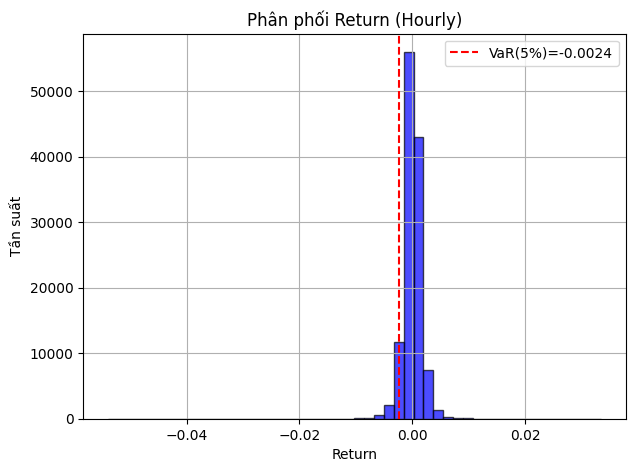

In [37]:
def plot_return_distribution(all_hourly_returns, alpha=0.05):
    """
    all_hourly_returns: shape (N, 3)
    alpha: mức cắt VaR, default 5%
    """
    import numpy as np

    r = all_hourly_returns.flatten()

    var_val = np.percentile(r, 100*alpha)   # VaR(5%)

    plt.figure(figsize=(7,5))
    plt.hist(r, bins=50, alpha=0.7, color='blue', edgecolor='black')
    plt.axvline(var_val, color='red', linestyle='--', label=f"VaR({int(alpha*100)}%)={var_val:.4f}")
    plt.title("Phân phối Return (Hourly)")
    plt.xlabel("Return")
    plt.ylabel("Tần suất")
    plt.legend()
    plt.grid(True)
    plt.show()
# all_hourly_returns shape (N, 3)
plot_return_distribution(all_hourly_returns, alpha=0.05)


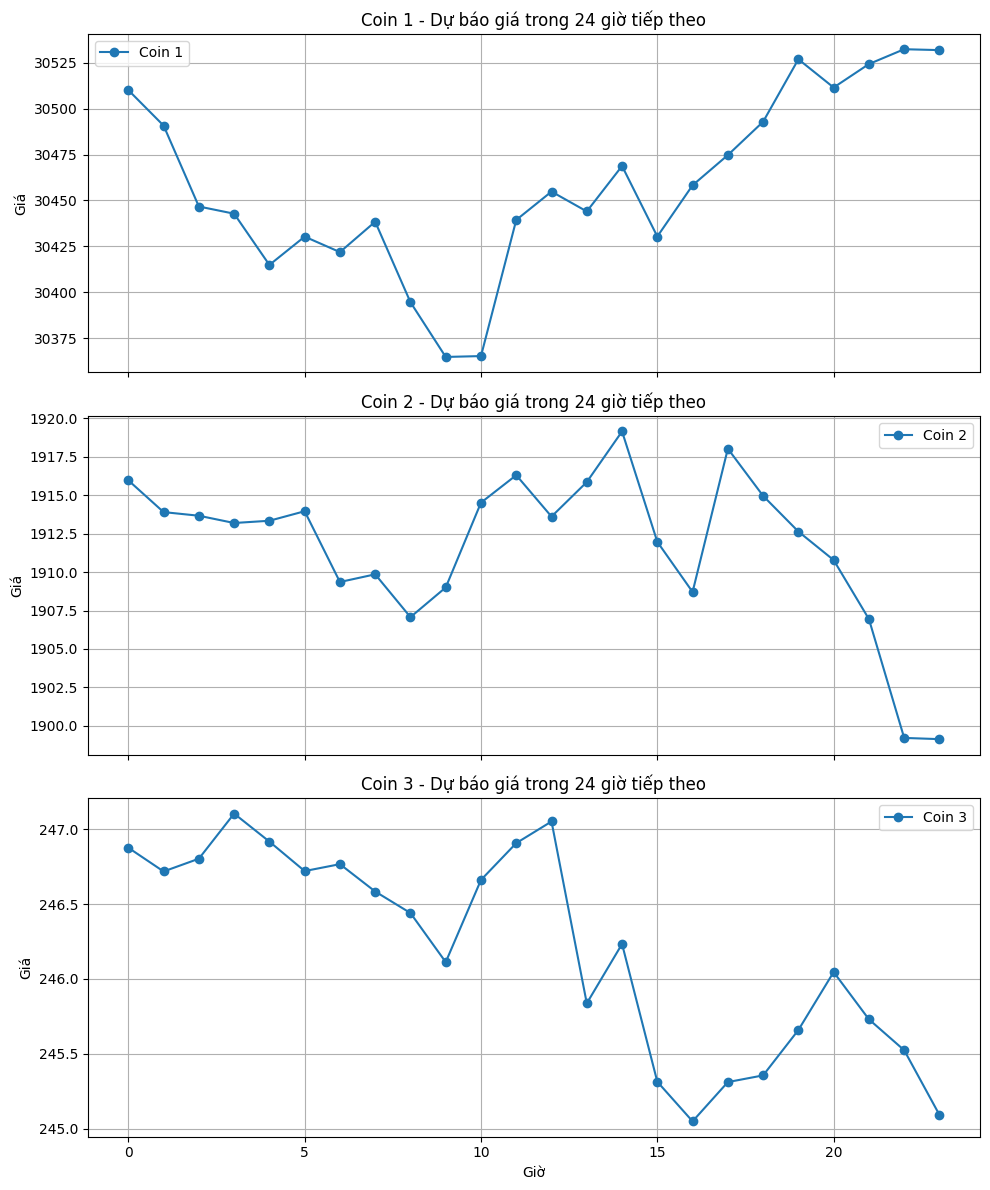

In [38]:
import matplotlib.pyplot as plt
import numpy as np

# Giả sử forecast_price_path là mảng NumPy có shape (24, 3)
# Ví dụ giả lập dữ liệu (bạn thay thế bằng dữ liệu dự báo thực của mình)
# forecast_price_path = np.random.rand(24, 3) * 1000  # thay bằng dữ liệu thực

hours = np.arange(24)  # từ 0 đến 23, mỗi giá trị ứng với 1 giờ
coin_names = ['Coin 1', 'Coin 2', 'Coin 3']

# Tạo 3 subplot (một cho mỗi coin)
fig, axs = plt.subplots(3, 1, figsize=(10, 12), sharex=True)

for i in range(3):
    axs[i].plot(hours, forecast_price_path[:, i], marker='o', linestyle='-', label=coin_names[i])
    axs[i].set_title(f'{coin_names[i]} - Dự báo giá trong 24 giờ tiếp theo')
    axs[i].set_ylabel("Giá")
    axs[i].legend()
    axs[i].grid(True)

axs[-1].set_xlabel("Giờ")

plt.tight_layout()
plt.show()


<ipython-input-39-fdd432b6cdd4>:13: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  price_path = init_price * np.exp(cum_log)


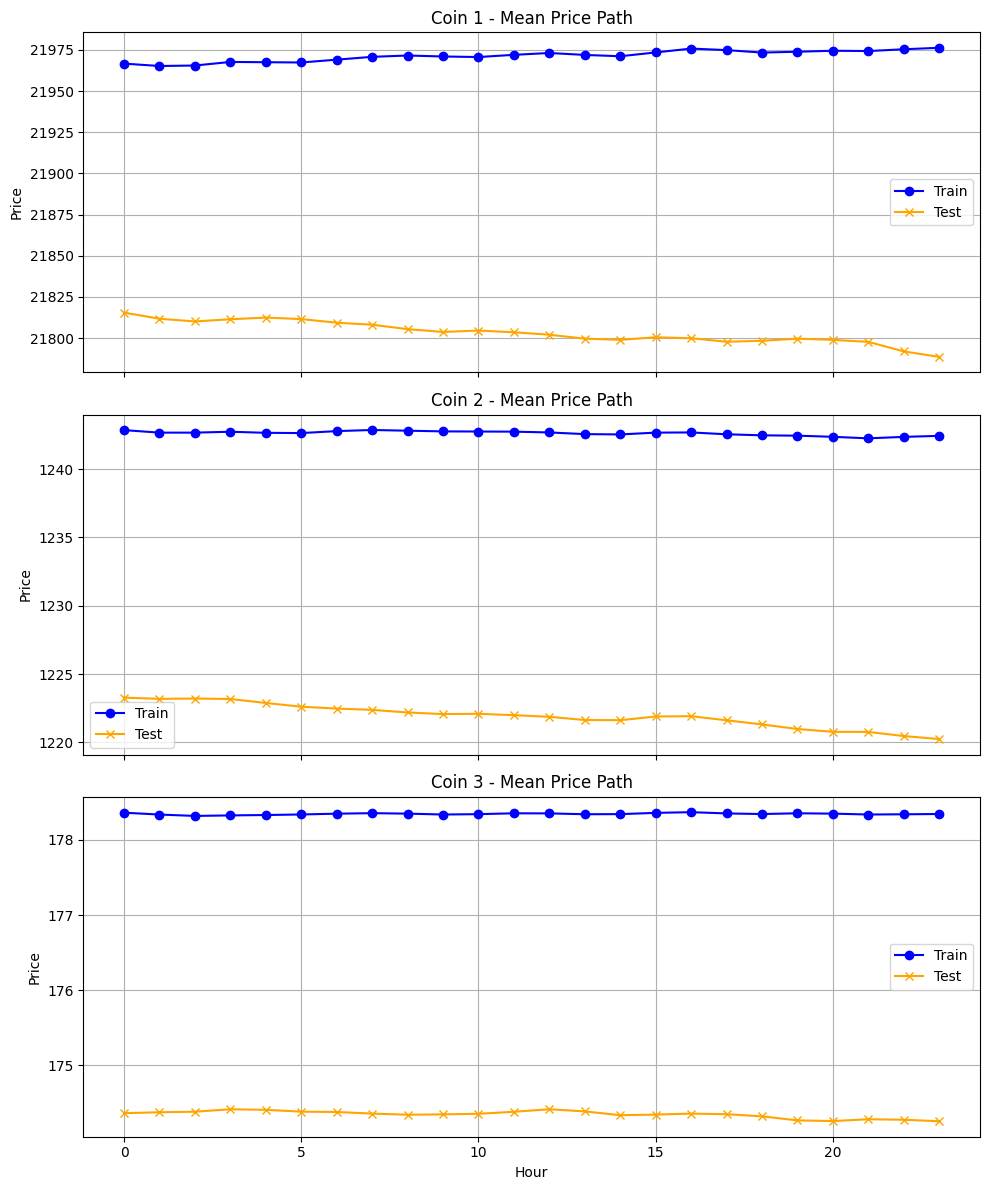

In [39]:
import numpy as np
import matplotlib.pyplot as plt

# Giả sử hàm chuyển đổi log-return thành price đã được định nghĩa:
def log_return_to_price(init_price, forecast_log):
    """
    Chuyển chuỗi log-return thành chuỗi giá.
    init_price: np.array shape (3,) – giá khởi đầu cho 3 coin
    forecast_log: np.array shape (24, 3) – chuỗi log-return theo giờ trong 24h
    return: np.array shape (24, 3) – chuỗi giá tại mỗi giờ
    """
    cum_log = np.cumsum(forecast_log, axis=0)  # (24, 3)
    price_path = init_price * np.exp(cum_log)
    return price_path

# Hàm tính chuỗi giá (price path) cho toàn bộ mẫu trong một tập
def compute_price_paths(log_returns_subset, init_prices_subset):
    """
    log_returns_subset: shape (n_samples, 24, 3)
    init_prices_subset: shape (n_samples, 1, 3)
    return: price_paths: shape (n_samples, 24, 3)
    """
    n_samples = log_returns_subset.shape[0]
    price_paths = []
    for i in range(n_samples):
        # Lấy giá khởi đầu của mẫu thứ i (shape (3,))
        init_p = init_prices_subset[i, 0, :]
        price_path = log_return_to_price(init_p, log_returns_subset[i])
        price_paths.append(price_path)
    return np.array(price_paths)

# Chia dữ liệu gốc thành tập train và test theo thứ tự thời gian
# Ví dụ: sử dụng 80% đầu làm train, 20% cuối làm test
train_size = int(0.8 * log_returns.shape[0])
train_log_returns = log_returns[:train_size]         # shape: (train_size, 24, 3)
test_log_returns = log_returns[train_size:]          # shape: (remaining, 24, 3)
train_init_prices = init_price_data[:train_size]       # shape: (train_size, 1, 3)
test_init_prices = init_price_data[train_size:]        # shape: (remaining, 1, 3)

# Tính chuỗi giá cho từng mẫu trong train và test
train_price_paths = compute_price_paths(train_log_returns, train_init_prices)  # (train_size, 24, 3)
test_price_paths = compute_price_paths(test_log_returns, test_init_prices)     # (test_size, 24, 3)

# Tính đường giá trung bình (mean price path) cho từng coin, theo từng giờ trong 24h
mean_train = np.mean(train_price_paths, axis=0)  # shape: (24, 3)
mean_test  = np.mean(test_price_paths, axis=0)   # shape: (24, 3)

# Vẽ đồ thị so sánh trung bình train và test cho từng đồng coin
hours = np.arange(24)  # 0 đến 23 giờ
coin_names = ['Coin 1', 'Coin 2', 'Coin 3']

fig, axs = plt.subplots(3, 1, figsize=(10, 12), sharex=True)

for i in range(3):
    axs[i].plot(hours, mean_train[:, i], label='Train', color='blue', marker='o')
    axs[i].plot(hours, mean_test[:, i], label='Test', color='orange', marker='x')
    axs[i].set_title(f"{coin_names[i]} - Mean Price Path")
    axs[i].set_ylabel("Price")
    axs[i].legend()
    axs[i].grid(True)

axs[-1].set_xlabel("Hour")
plt.tight_layout()
plt.show()
